# Получение оригинальной матрицы изображения

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"picture1.png"  #никакой кириллицы тут в пути!!!
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError('Изображение не грузанулось')

img = cv2.resize(img, (256, 256))
imgf = img.astype(np.float64)
print(img)

[[ 58  61  61 ... 124 124 124]
 [ 58  60  61 ... 124 125 124]
 [ 60  60  61 ... 125 125 124]
 ...
 [ 97  96  94 ...  68  71  87]
 [170 170 169 ...  68  72  85]
 [216 217 216 ...  67  72  75]]


## Пример

In [4]:
# Пример изображения: 4x4 (мелкая матрица)
imgex = np.array([
    [52, 55, 61, 59],
    [62, 59, 55, 90],
    [63, 65, 66, 80],
    [58, 55, 52, 85]
], dtype=int)

# Вывод картинки

Оригинальное изображение


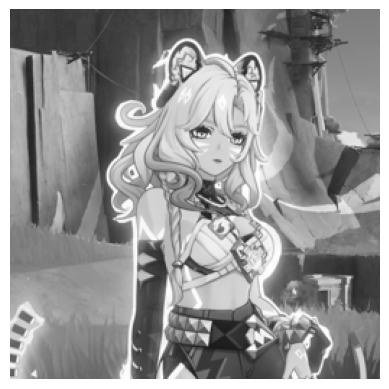

In [3]:
def show_matrix_as_image(matrix):
    plt.imshow(matrix, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.show()
print("Оригинальное изображение")
show_matrix_as_image(img)

# Преобразование 5/3

**Низкочастотная часть**

$$
c_k^{1,0} = c_{2k}^0,\quad k = 0, \ldots, N_1 - 1,
$$

$$
\left\{
\begin{aligned}
d_k^1 &= \text{int}\left( \frac{c_{2k}^0 + c_{2k+2}^0}{2} \right) - c_{2k+1}^0,\quad k = 0, \ldots, N_1 - 2, \\
d_{N_1 - 1}^1 &= c_{N - 2}^0 - c_{N - 1}^0,
\end{aligned}
\right.
$$

**Высокочастотная часть**

$$
\left\{
\begin{aligned}
c_0^1 &= c_0^{1,0} - \text{int}\left( \frac{d_0^1}{2} \right), \\
c_k^1 &= c_k^{1,0} - \text{int}\left( \frac{d_{k-1}^1 + d_k^1}{4} \right),\quad k = 1, \ldots, N_1 - 2, \\
c_{N_1 - 1}^1 &= c_{N_1 - 2}^{1,0} - \text{int}\left( \frac{d_{N_1 - 2}^1 + d_{N_1 - 1}^1}{4} \right)
\end{aligned}
\right.
$$


In [ ]:
def wavelet53_1d(C):
    N = len(C)
    N1 = int(N / 2)
    D1 = np.ndarray(N1)
    C1 = np.ndarray(N1)

    #Высокочастотная часть
    for k in range(0, N1 - 1):
        D1[k] = int((C[2 * k] + C[2 * k + 2]) / 2) - C[2 * k + 1]
    D1[N1 - 1] = C[N - 2] - C[N - 1]

    #Низкочастотная часть
    C1[0] = C[0] - int(D1[0] / 2)
    for k in range(1, N1 - 1):
        C1[k] = C[2 * k] - int((D1[k - 1] + D1[k]) / 4)
    C1[N1 - 1] = C[2 * (N1 - 2)] - int((D1[N1 - 2] + D1[N1 - 1]) / 4)

    return np.concatenate([C1, D1])


In [6]:
def wavelet53_2d(matrix):
    h, w = matrix.shape
    temp = matrix.copy()

    # Применяем по строкам
    for i in range(h):
        temp[i, :] = wavelet53_1d(temp[i, :])

    # Применяем по столбцам
    for j in range(w):
        temp[:, j] = wavelet53_1d(temp[:, j])

    return temp

## Пример

In [16]:
preobr_imgex = wavelet53_2d(imgex)
print(preobr_imgex)

[[ 54  58   1 -12]
 [ 52  55   1 -10]
 [ -5 -12   1  29]
 [  5   0  -1  19]]


# Обратное преобразование

$$
\begin{aligned}
c_0^0 &= c_0^1 + \text{int} \left( \frac{d_0^1}{2} \right), \\
c_{2k}^0 &= c_k^1 + \text{int} \left( \frac{d_{k-1}^1 + d_k^1}{4} \right), \quad k = 1, \dots, N_1 - 2, \\
c_{N-2}^0 &= c_{N_1-1}^1 + \text{int} \left( \frac{d_{N_1-2}^1 + d_{N_1-1}^1}{4} \right), \\
c_{2k+1}^0 &= \text{int} \left( \frac{c_{2k}^0 + c_{2k+2}^0}{2} \right) - d_k^1, \quad k = 0, \dots, N_1 - 2, \\
c_{N-1}^0 &= c_{N-2}^0 - d_{N_1-2}^1.
\end{aligned}
$$

In [ ]:
def wavelet53_1d_back(signal):
    N = len(signal)
    N1 = int(N / 2)
    D1 = signal[N1:]
    C1 = signal[:N1]
    C0 = np.ndarray(N)

    C0[0] = C1[0] + int(D1[0] / 2)

    #Чётные
    for k in range(1, N1 - 1):
        C0[2 * k] = C1[k] + int((D1[k - 1] + D1[k]) / 4)
    C0[N - 2] = C1[N1 - 1] + int((D1[N1 - 2] + D1[N1 - 1]) / 4)

    #Нечётные
    for k in range(0, N1 -1):
        C0[2 * k + 1] = int((C0[2 * k] + C0[2 * k + 2]) / 2) - D1[k]
    C0[N - 1] = C0[N - 2] - D1[N1 - 2]

    return C0

def wavelet53_2d_back(M1, M2, M3, M4):  #Матрицу надо склеивать из нескольких кусков
    matrix = np.vstack((np.hstack((M1, M2)), np.hstack((M3, M4))))
    h, w = matrix.shape
    temp = matrix.copy()

    # Применяем по столбцам
    for j in range(w):
        temp[:, j] = wavelet53_1d_back(temp[:, j])
    
    # Применяем по строкам
    for i in range(h):
        temp[i, :] = wavelet53_1d_back(temp[i, :])

    return temp


def wavelet53_2d_back_short(matrix):
    h, w = matrix.shape
    temp = matrix.copy()

    # Применяем по столбцам
    for j in range(w):
        temp[:, j] = wavelet53_1d_back(temp[:, j])
    
    # Применяем по строкам
    for i in range(h):
        temp[i, :] = wavelet53_1d_back(temp[i, :])

    return temp

# Квантование

In [77]:
def quant(mat, d):
    shir = len(mat[0])     #ширина матрицы
    vi = len(mat)       #высота матрицы
    
    for i in range(vi):
        for j in range(shir):
            mat[i][j] = round(mat[i][j] / d) * d
    return mat

# Один шаг декомпозиции без потерь

In [79]:
preobr_imgex = wavelet53_2d(imgex)
print(preobr_imgex)

print(wavelet53_2d_back_short(preobr_imgex))
print(imgex)

[[ 54  58   1 -12]
 [ 52  55   1 -10]
 [ -5 -12   1  29]
 [  5   0  -1  19]]
[[52 51 52 51]
 [57 57 58 58]
 [52 51 52 51]
 [57 57 58 58]]
[[52 55 61 59]
 [62 59 55 90]
 [63 65 66 80]
 [58 55 52 85]]


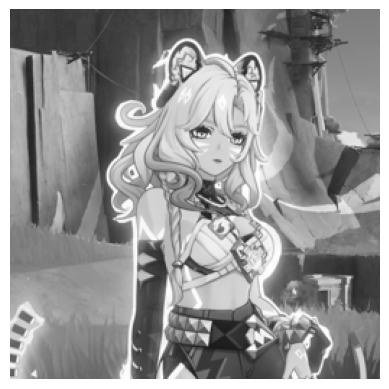

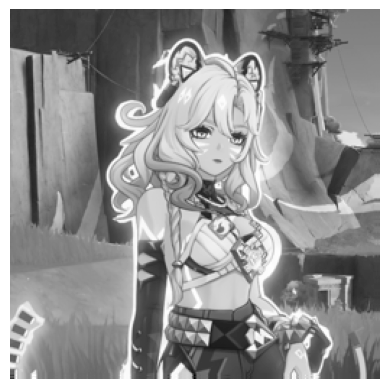

[[ 58.  61.  61. ... 124. 124. 124.]
 [ 58.  60.  61. ... 124. 125. 124.]
 [ 60.  60.  61. ... 125. 125. 124.]
 ...
 [ 97.  96.  94. ...  68.  71.  87.]
 [170. 170. 169. ...  68.  72.  85.]
 [216. 217. 216. ...  67.  72.  75.]]
[[ 58.  61.  61. ... 124. 123. 124.]
 [ 58.  60.  61. ... 124. 124. 124.]
 [ 60.  60.  61. ... 125. 125. 125.]
 ...
 [ 63.  62.  59. ...  66.  66.  65.]
 [101. 100.  98. ...  67.  67.  67.]
 [ 63.  62.  59. ...  66.  66.  65.]]


In [80]:
preobr_img = wavelet53_2d(imgf)
img_back = wavelet53_2d_back_short(preobr_img)

show_matrix_as_image(imgf)
show_matrix_as_image(img_back)

print(imgf)
print(img_back)

# «Cобранные» программы

## Квантование + сохранение только LL на первых трёх шагах

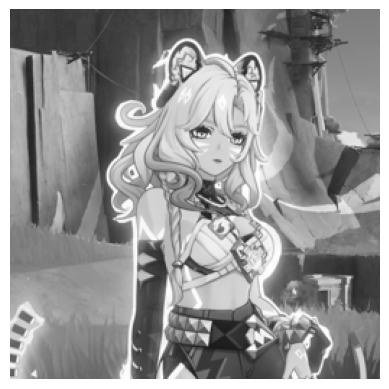

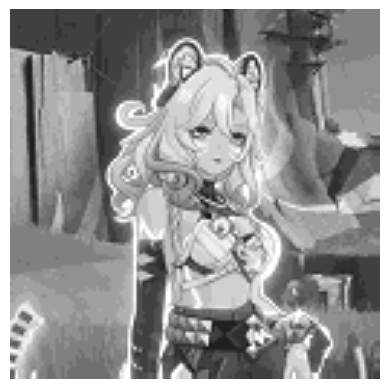

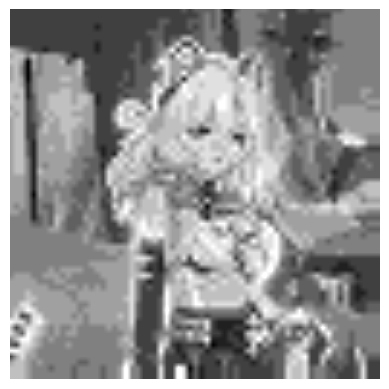

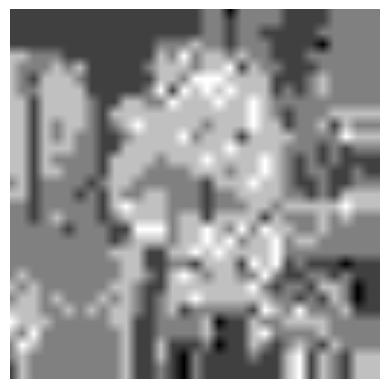

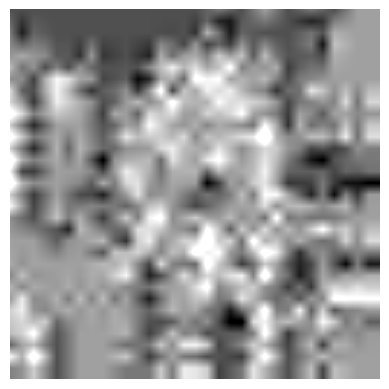

Средняя дисперсия:  2257.0541076660156


In [82]:
show_matrix_as_image(img)

loc_res = wavelet53_2d(imgf)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL1 = quant(loc_res[:new_shir, :new_vi], 16)

inv1 = wavelet53_2d_back(LL1, np.zeros_like(LL1), np.zeros_like(LL1), np.zeros_like(LL1))
show_matrix_as_image(inv1)


loc_res = wavelet53_2d(LL1)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL2 = quant(loc_res[:new_shir, :new_vi], 32)

inv2 = wavelet53_2d_back(LL2, np.zeros_like(LL2), np.zeros_like(LL2), np.zeros_like(LL2))
inv1 = wavelet53_2d_back(inv2, np.zeros_like(inv2), np.zeros_like(inv2), np.zeros_like(inv2))
show_matrix_as_image(inv1)


loc_res = wavelet53_2d(LL2)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL3 = quant(loc_res[:new_shir, :new_vi], 64)

inv3 = wavelet53_2d_back(LL3, np.zeros_like(LL3), np.zeros_like(LL3), np.zeros_like(LL3))
inv2 = wavelet53_2d_back(inv3, np.zeros_like(inv3), np.zeros_like(inv3), np.zeros_like(inv3))
inv1 = wavelet53_2d_back(inv2, np.zeros_like(inv2), np.zeros_like(inv2), np.zeros_like(inv2))
show_matrix_as_image(inv1)


loc_res = wavelet53_2d(LL3)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL4 = quant(loc_res[:new_shir, :new_vi], 80)
LH4 = quant(loc_res[new_shir:, :new_vi], 80)
HL4 = quant(loc_res[:new_shir, new_vi:], 80)
HH4 = quant(loc_res[new_shir:, new_vi:], 80)   


LL3 = wavelet53_2d_back(LL4, LH4, HL4, HH4)
LL2 = wavelet53_2d_back(LL3, np.zeros_like(LL3), np.zeros_like(LL3), np.zeros_like(LL3))
LL1 = wavelet53_2d_back(LL2, np.zeros_like(LL2), np.zeros_like(LL2), np.zeros_like(LL2))
LL = wavelet53_2d_back(LL1, np.zeros_like(LL1), np.zeros_like(LL1), np.zeros_like(LL1))

show_matrix_as_image(LL)

disp = 0
for i in range(0, 256):
    for j in range(0, 256):
        disp = disp + ((imgf[i][j] - LL[i][j]) / 256) ** 2
print("Средняя дисперсия: ", disp)

## Без квантования + сохранение всех доп компонент

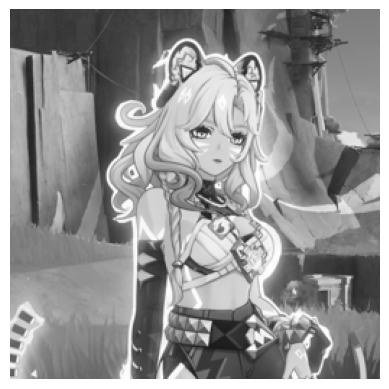

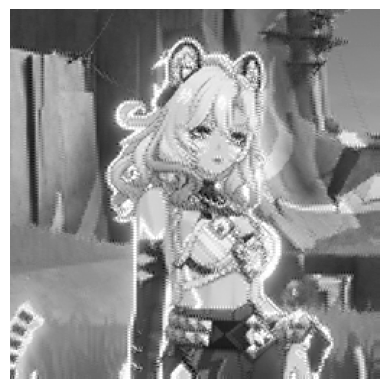

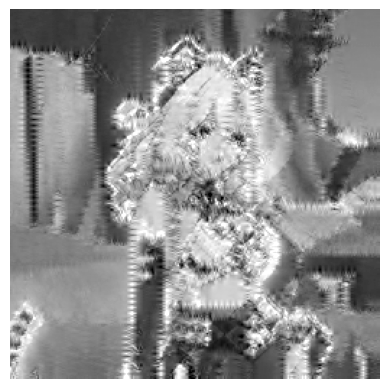

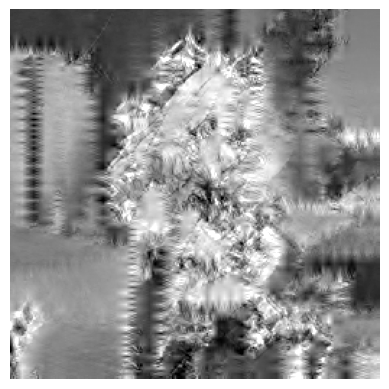

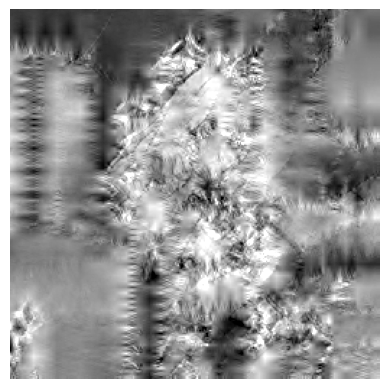

Средняя дисперсия:  1958.4841918945312


In [83]:
show_matrix_as_image(img)

loc_res = wavelet53_2d(imgf)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL1 = loc_res[:new_shir, :new_vi]
LH1 = loc_res[new_shir:, :new_vi]
HL1 = loc_res[:new_shir, new_vi:]
HH1 = loc_res[new_shir:, new_vi:]

inv1 = wavelet53_2d_back(LL1, LH1, HL1, HH1)
show_matrix_as_image(inv1)


loc_res = wavelet53_2d(LL1)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL2 = loc_res[:new_shir, :new_vi]
LH2 = loc_res[new_shir:, :new_vi]
HL2 = loc_res[:new_shir, new_vi:]
HH2 = loc_res[new_shir:, new_vi:]

inv2 = wavelet53_2d_back(LL2, LH2, HL2, HH2)
inv1 = wavelet53_2d_back(inv2, LH1, HL1, HH1)
show_matrix_as_image(inv1)


loc_res = wavelet53_2d(LL2)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL3 = loc_res[:new_shir, :new_vi]
LH3 = loc_res[new_shir:, :new_vi]
HL3 = loc_res[:new_shir, new_vi:]
HH3 = loc_res[new_shir:, new_vi:]

inv3 = wavelet53_2d_back(LL3, LH3, HL3, HH3)
inv2 = wavelet53_2d_back(inv3, LH2, HL2, HH2)
inv1 = wavelet53_2d_back(inv2, LH1, HL1, HH1)
show_matrix_as_image(inv1)


loc_res = wavelet53_2d(LL3)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL4 = loc_res[:new_shir, :new_vi]
LH4 = loc_res[new_shir:, :new_vi]
HL4 = loc_res[:new_shir, new_vi:]
HH4 = loc_res[new_shir:, new_vi:]

LL3 = wavelet53_2d_back(LL4, LH4, HL4, HH4)
LL2 = wavelet53_2d_back(LL3, LH3, HL3, HH3)
LL1 = wavelet53_2d_back(LL2, LH2, HL2, HH2)
LL = wavelet53_2d_back(LL1, LH1, HL1, HH1)

show_matrix_as_image(LL)

disp = 0
for i in range(0, 256):
    for j in range(0, 256):
        disp = disp + ((imgf[i][j] - LL[i][j]) / 256) ** 2
print("Средняя дисперсия: ", disp)